# PCA Analysis — merge_test.csv\nReplicating the approach from `legacy/fix feature matrix.ipynb` on our new extracted features.

In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
import seaborn as sns
import matplotlib.pyplot as plt

## Step 1 — Load & Inspect

In [2]:
df = pd.read_csv("../utterances_v2/merge_test.csv")
print(f"Shape: {df.shape}")
print(f"\nDtypes:\n{df.dtypes}")
print(f"\nNull counts:\n{df.isnull().sum()}")

Shape: (214204, 39)

Dtypes:
Utterance File Name                      str
Transcript                               str
Gender                                   str
Region                                   str
Year Born                              int64
Generation                               str
Decade                                   str
Education                              int64
Filler Word Rate                     float64
Filler Words per Second              float64
Pronoun Rate                         float64
Pronouns per Second                  float64
Repetition Rate                      float64
Repetitions per Second               float64
syllable_rate                        float64
pitch mean                           float64
pitch std                            float64
pitch range                          float64
loudness mean                        float64
loudness std                         float64
loudness range                       float64
Turn Gap                  

## Step 2 — Select Feature Columns (no pitch)

In [3]:
feature_cols = [
    "Filler Word Rate",
    "Pronoun Rate",
    "Repetition Rate",
    "syllable_rate",
    "loudness mean",
    "loudness std",
    "loudness range",
    "Turn Gap",
    "word_rate",
    "token_count",
    "Repetitions In Current Utterance",
    "Repetitions In Previous Utterance",
]
print(f"Feature columns ({len(feature_cols)}): {feature_cols}")

Feature columns (12): ['Filler Word Rate', 'Pronoun Rate', 'Repetition Rate', 'syllable_rate', 'loudness mean', 'loudness std', 'loudness range', 'Turn Gap', 'word_rate', 'token_count', 'Repetitions In Current Utterance', 'Repetitions In Previous Utterance']


## Step 3 — Clean (drop NaN/inf rows in feature columns)

In [4]:
before = len(df)
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=feature_cols)
print(f"Rows before: {before}, after: {len(df)}, dropped: {before - len(df)}")

Rows before: 214204, after: 212210, dropped: 1994


## Step 4 — Normalize & PCA

In [5]:
X = df[feature_cols].values
X_norm = normalize(X)

n_components = len(feature_cols)
pca = PCA(n_components=n_components)
pca_result = pca.fit_transform(X_norm)

pca_cols = [f"pca{i}" for i in range(n_components)]
for i, col in enumerate(pca_cols):
    df[col] = pca_result[:, i]

print(f"PCA components: {n_components}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Cumulative variance: {np.cumsum(pca.explained_variance_ratio_)}")

PCA components: 12
Explained variance ratio: [5.77322285e-01 1.81241984e-01 1.08913014e-01 7.58598666e-02
 3.03893022e-02 1.42932791e-02 8.41220867e-03 2.65822655e-03
 7.01675535e-04 2.06502574e-04 1.40224128e-06 2.54176444e-07]
Cumulative variance: [0.57732228 0.75856427 0.86747728 0.94333715 0.97372645 0.98801973
 0.99643194 0.99909017 0.99979184 0.99999834 0.99999975 1.        ]


## Step 5 — Histogram of PC0 & Explained Variance

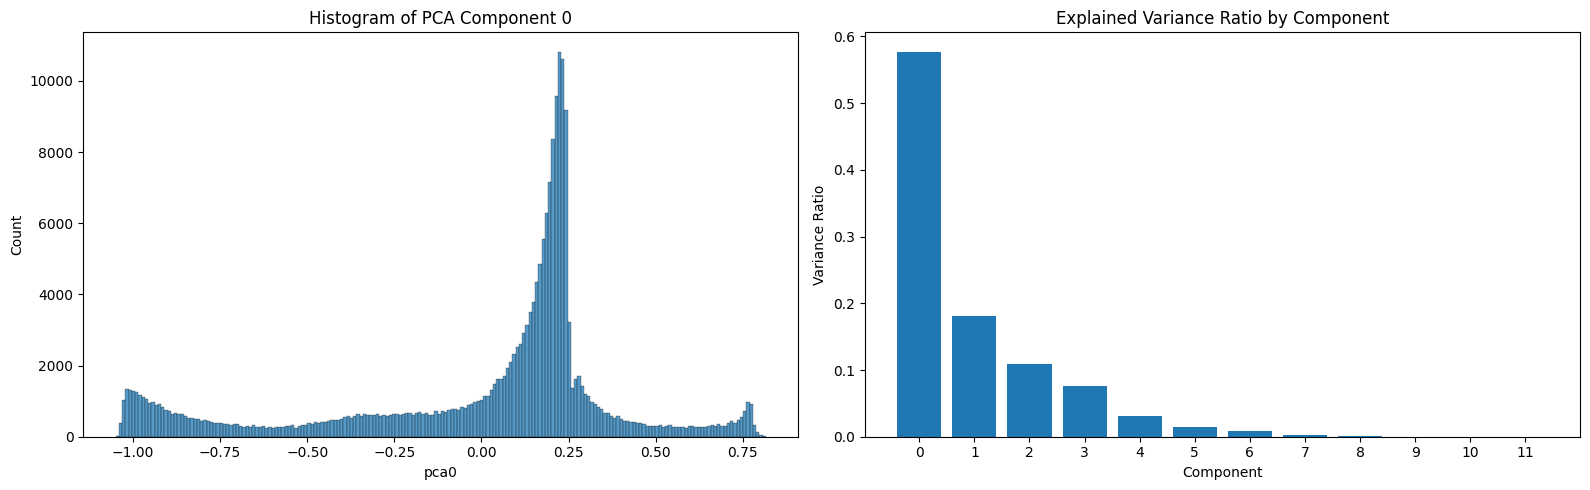

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(df["pca0"], bins=200, ax=axes[0])
axes[0].set_title("Histogram of PCA Component 0")
axes[0].set_xlabel("pca0")

axes[1].bar(range(n_components), pca.explained_variance_ratio_)
axes[1].set_title("Explained Variance Ratio by Component")
axes[1].set_xlabel("Component")
axes[1].set_ylabel("Variance Ratio")
axes[1].set_xticks(range(n_components))

plt.tight_layout()
plt.show()

## Step 6 — Table 2: Feature Importance to Principal Component\n\nReplicates Table 2 from *Determining Conversational Styles at Scale*. The values are the entries of `pca.components_[0]` — the loading of each input feature on PC0 — sorted by absolute magnitude. Sign of PC0 is arbitrary in PCA, so the overall sign may flip vs. the paper while the relative magnitudes still characterize the same axis.

In [7]:
loadings = pd.DataFrame({
    "Feature": feature_cols,
    "Magnitude": pca.components_[0],
})
loadings = (
    loadings.assign(_abs=loadings["Magnitude"].abs())
    .sort_values("_abs", ascending=False)
    .drop(columns="_abs")
    .reset_index(drop=True)
)
loadings["Magnitude"] = loadings["Magnitude"].apply(lambda x: f"{x:+.4f}")
loadings = loadings[["Magnitude", "Feature"]]
print("Table 2: Feature importance to Principal Component (PC0)\n")
print(loadings.to_string(index=False))

Table 2: Feature importance to Principal Component (PC0)

Magnitude                           Feature
  +0.9045                          Turn Gap
  +0.4080                       token_count
  +0.1058  Repetitions In Current Utterance
  +0.0528 Repetitions In Previous Utterance
  -0.0285                     syllable_rate
  -0.0257                         word_rate
  -0.0055                  Filler Word Rate
  +0.0040                      Pronoun Rate
  -0.0022                    loudness range
  +0.0021                   Repetition Rate
  -0.0007                      loudness std
  -0.0004                     loudness mean


## Step 7 — Silhouette Analysis (pick best GMM k)\n\nFor each candidate `k` in 2..10, fit a Gaussian Mixture Model with `k` components on PC0, take hard labels via `gmm.predict()`, then compute the average silhouette score:\n\n- For each point: **a** = mean distance to other points in its own cluster, **b** = mean distance to points in the nearest other cluster. Silhouette = (b − a) / max(a, b), in [-1, +1].\n- +1 = tight, well-separated cluster; 0 = on a boundary; −1 = probably mislabeled.\n- We pick the `k` with the highest mean silhouette — the clustering where groups are most internally tight and most externally separated.\n\nNote: `silhouette_score` is O(n²); with 212k points we subsample (`sample_size=10000`) for tractability. The paper found k=2 best.

In [8]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

X = df["pca0"].values.reshape(-1, 1)
ks = list(range(2, 11))
sil_scores = []
for k in ks:
    gmm_k = GaussianMixture(n_components=k, random_state=0).fit(X)
    labels = gmm_k.predict(X)
    score = silhouette_score(X, labels, sample_size=10000, random_state=0)
    sil_scores.append(score)
    print(f"k={k}: silhouette = {score:.4f}")

best_k = ks[int(np.argmax(sil_scores))]
print(f"\nBest k by silhouette: {best_k}")

k=2: silhouette = 0.7438


k=3: silhouette = 0.6865


k=4: silhouette = 0.6143


k=5: silhouette = 0.6128


k=6: silhouette = 0.5879


k=7: silhouette = 0.6062


k=8: silhouette = 0.5993


k=9: silhouette = 0.5824


k=10: silhouette = 0.5821

Best k by silhouette: 2


## Step 8 — BIC across k = 1..10\n\nBIC (Bayesian Information Criterion) is a model-selection score: **lower = better**. It rewards fit (likelihood) and penalizes complexity (each extra Gaussian costs `~3 · log(n)` ≈ 36 in BIC). Unlike silhouette, BIC **can pick k=1** — so if no clustering existed, k=1 would win. We compare to the silhouette result above.

In [9]:
print(f"{'k':>3} {'BIC':>14} {'Δ from k-1':>14}")
print("-" * 36)
bics = []
prev = None
for k in range(1, 11):
    gmm_k = GaussianMixture(n_components=k, random_state=0).fit(X)
    bic = gmm_k.bic(X)
    bics.append(bic)
    delta = "" if prev is None else f"{bic - prev:+.0f}"
    print(f"{k:>3} {bic:>14.0f} {delta:>14}")
    prev = bic

best_k_bic = int(np.argmin(bics)) + 1
print(f"\nBest k by BIC: {best_k_bic}")
print(f"Best k by silhouette: {best_k}")

  k            BIC     Δ from k-1
------------------------------------
  1         235522               
  2         129404        -106118


  3         108612         -20792


  4          25734         -82878


  5          21779          -3955


  6          16814          -4965


  7          10045          -6769


  8           6937          -3107


  9           3823          -3114


 10           1647          -2176

Best k by BIC: 10
Best k by silhouette: 2


## Step 9 — Fit best-k GMM and overlay on histogram\n\nRefits a GMM at the chosen `k`, prints per-component mean/std/weight, and overlays each Gaussian density on the PC0 histogram. Hard labels (per-row argmax of posterior probability) are added back to `df` as `gmm_label` — this matches the paper's HC/HI assignment rule.

GMM with k=2 components:
  component 1: mean=-0.7001, std=0.2688, weight=0.213
  component 0: mean=+0.1895, std=0.1938, weight=0.787


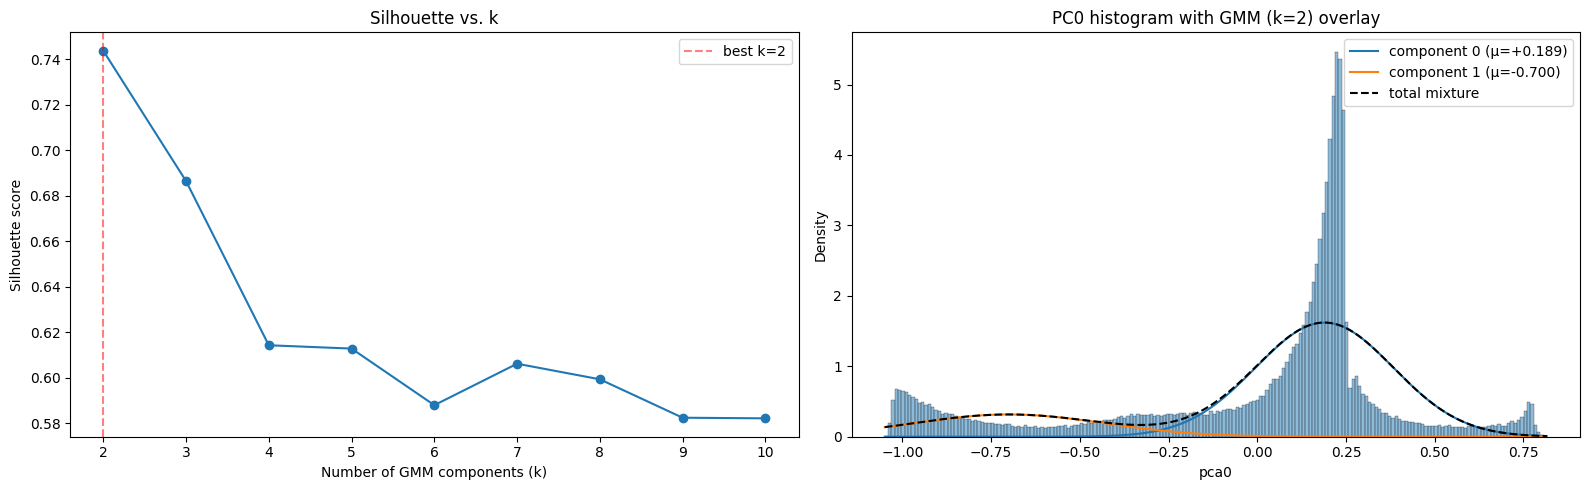


Hard label counts: {0: 167755, 1: 44455}


In [10]:
best_gmm = GaussianMixture(n_components=best_k, random_state=0).fit(X)
means = best_gmm.means_.flatten()
stds = np.sqrt(best_gmm.covariances_.flatten())
weights = best_gmm.weights_
order = np.argsort(means)
print(f"GMM with k={best_k} components:")
for i in order:
    print(f"  component {i}: mean={means[i]:+.4f}, std={stds[i]:.4f}, weight={weights[i]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(ks, sil_scores, "o-")
axes[0].axvline(best_k, color="red", linestyle="--", alpha=0.5, label=f"best k={best_k}")
axes[0].set_xlabel("Number of GMM components (k)")
axes[0].set_ylabel("Silhouette score")
axes[0].set_title("Silhouette vs. k")
axes[0].legend()

sns.histplot(df["pca0"], bins=200, stat="density", ax=axes[1], alpha=0.5)
xs = np.linspace(X.min(), X.max(), 1000)
total = np.zeros_like(xs)
for i in range(best_k):
    component = (
        weights[i]
        * (1 / (stds[i] * np.sqrt(2 * np.pi)))
        * np.exp(-0.5 * ((xs - means[i]) / stds[i]) ** 2)
    )
    axes[1].plot(xs, component, label=f"component {i} (μ={means[i]:+.3f})")
    total += component
axes[1].plot(xs, total, "k--", label="total mixture")
axes[1].set_xlabel("pca0")
axes[1].set_title(f"PC0 histogram with GMM (k={best_k}) overlay")
axes[1].legend()

plt.tight_layout()
plt.show()

df["gmm_label"] = best_gmm.predict(X)
print(f"\nHard label counts: {df['gmm_label'].value_counts().to_dict()}")

## Step 10 — Export

In [11]:
output_path = "../utterances_v2/test_analysis_PCA_552026.csv"
df.to_csv(output_path, index=False)
print(f"Saved {len(df)} rows x {len(df.columns)} columns to {output_path}")

Saved 212210 rows x 52 columns to ../utterances_v2/test_analysis_PCA_552026.csv
